In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
df = pd.read_csv('heart.csv')
print(f'Розмір датасету: {df.shape}')
df.head(10)

Розмір датасету: (918, 12)


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,Sex,ChestPainType,FastingBS,RestingECG,ExerciseAngina,ST_Slope,HeartDisease
0,40,140,289,172,0.0,M,ATA,0,Normal,N,Up,0
1,49,160,180,156,1.0,F,NAP,0,Normal,N,Flat,1
2,37,130,283,98,0.0,M,ATA,0,ST,N,Up,0
3,48,138,214,108,1.5,F,ASY,0,Normal,Y,Flat,1
4,54,150,195,122,0.0,M,NAP,0,Normal,N,Up,0
5,39,120,339,170,0.0,M,NAP,0,Normal,N,Up,0
6,45,130,237,170,0.0,F,ATA,0,Normal,N,Up,0
7,54,110,208,142,0.0,M,ATA,0,Normal,N,Up,0
8,37,140,207,130,1.5,M,ASY,0,Normal,Y,Flat,1
9,48,120,284,120,0.0,F,ATA,0,Normal,N,Up,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   RestingBP       918 non-null    int64  
 2   Cholesterol     918 non-null    int64  
 3   MaxHR           918 non-null    int64  
 4   Oldpeak         918 non-null    float64
 5   Sex             918 non-null    str    
 6   ChestPainType   918 non-null    str    
 7   FastingBS       918 non-null    int64  
 8   RestingECG      918 non-null    str    
 9   ExerciseAngina  918 non-null    str    
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [4]:
df.describe()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,FastingBS,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,136.809368,0.887364,0.233115,0.553377
std,9.432617,18.514154,109.384145,25.460334,1.066570,0.423046,0.497414
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,47.000000,120.000000,173.250000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,138.000000,0.600000,0.000000,1.000000
75%,60.000000,140.000000,267.000000,156.000000,1.500000,0.000000,1.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,1.000000,1.000000


In [5]:
df.isnull().sum()

Age               0
RestingBP         0
Cholesterol       0
MaxHR             0
Oldpeak           0
Sex               0
ChestPainType     0
FastingBS         0
RestingECG        0
ExerciseAngina    0
ST_Slope          0
HeartDisease      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df = df.drop_duplicates()
print(f'Розмір після видалення дублікатів: {df.shape}')

Розмір після видалення дублікатів: (918, 12)


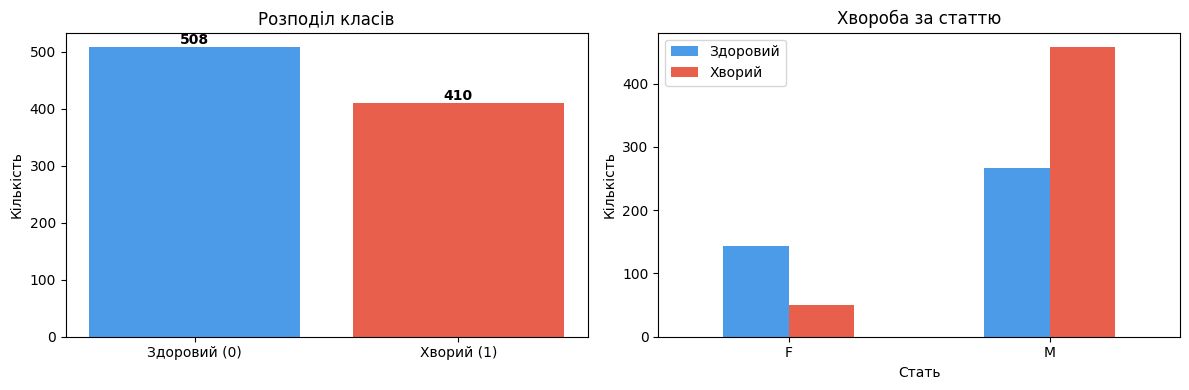

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['HeartDisease'].value_counts()
axes[0].bar(['Здоровий (0)', 'Хворий (1)'], counts.values, color=['#4C9BE8', '#E8604C'])
axes[0].set_title('Розподіл класів')
axes[0].set_ylabel('Кількість')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

sex_disease = df.groupby(['Sex', 'HeartDisease']).size().unstack()
sex_disease.plot(kind='bar', ax=axes[1], color=['#4C9BE8', '#E8604C'], rot=0)
axes[1].set_title('Хвороба за статтю')
axes[1].set_xlabel('Стать')
axes[1].set_ylabel('Кількість')
axes[1].legend(['Здоровий', 'Хворий'])

plt.tight_layout()
plt.show()

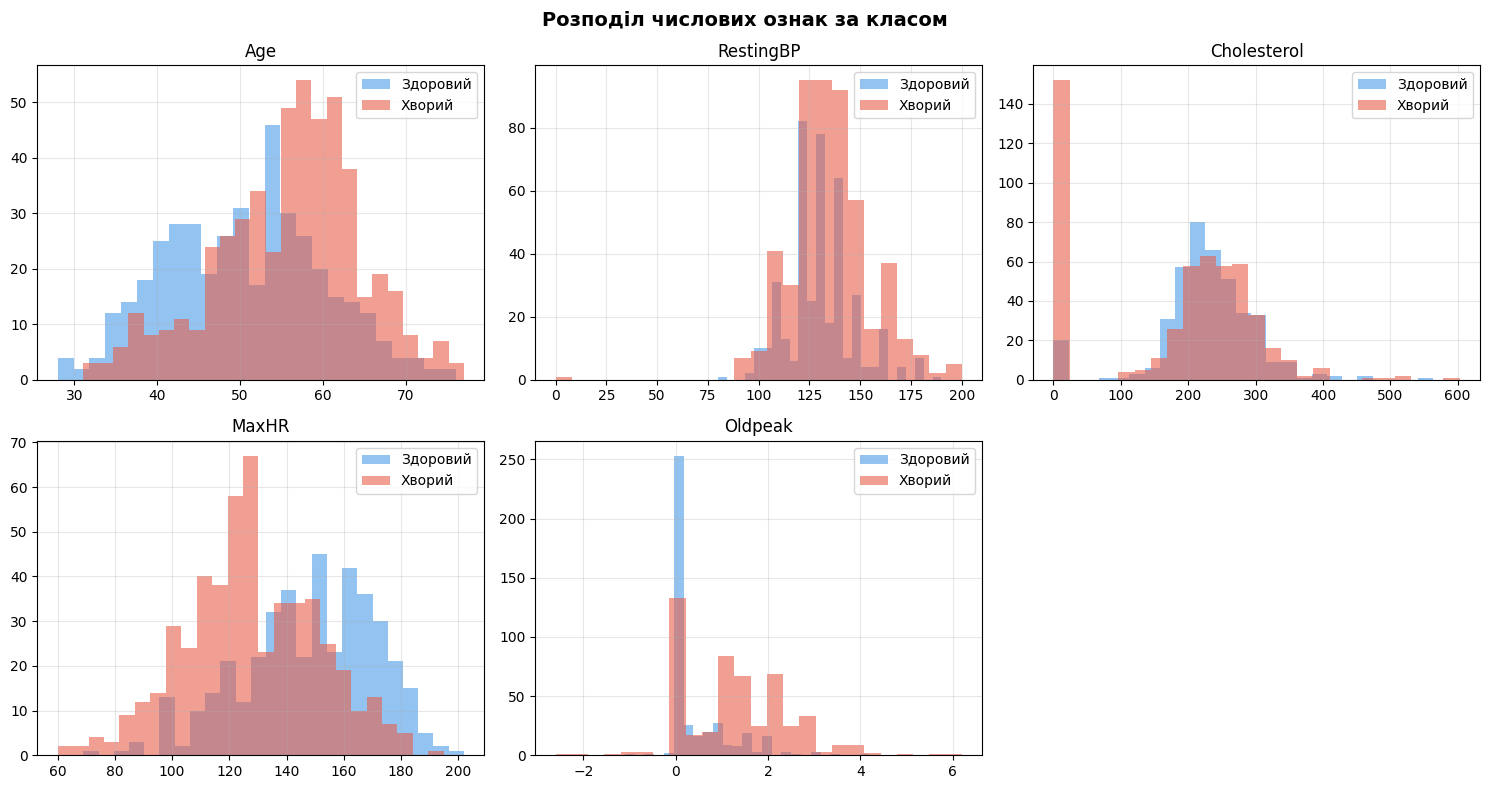

In [9]:
numCols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numCols):
    axes[i].hist(df[df['HeartDisease'] == 0][col], bins=25, alpha=0.6, label='Здоровий', color='#4C9BE8')
    axes[i].hist(df[df['HeartDisease'] == 1][col], bins=25, alpha=0.6, label='Хворий', color='#E8604C')
    axes[i].set_title(col)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

fig.delaxes(axes[5])
plt.suptitle('Розподіл числових ознак за класом', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

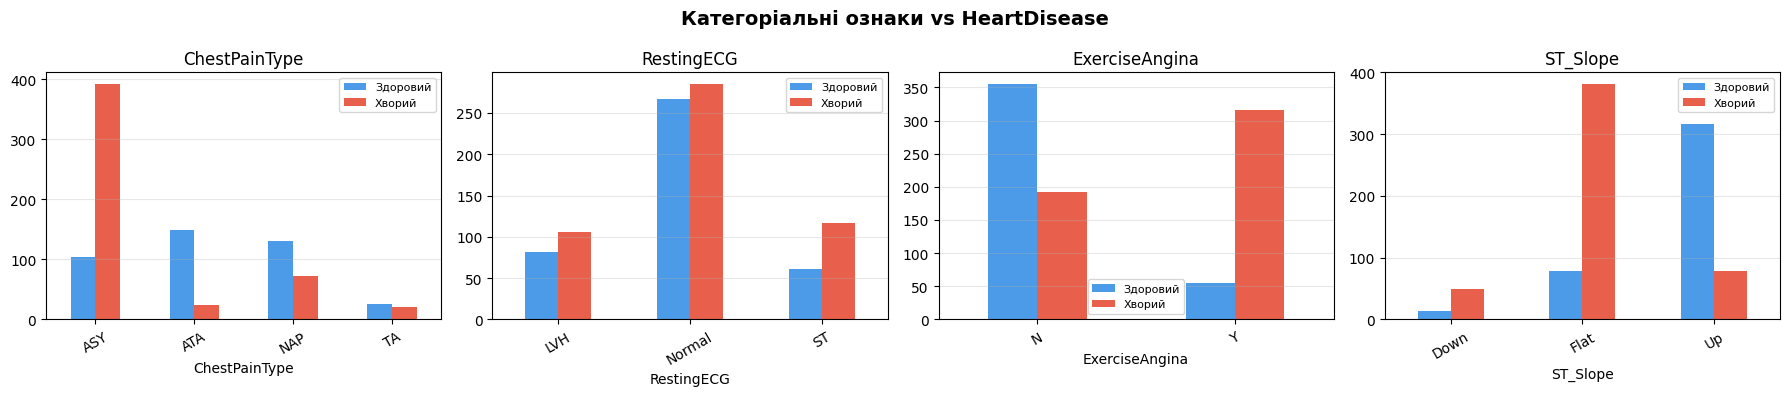

In [10]:
catCols = ['ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, catCols):
    grp = df.groupby([col, 'HeartDisease']).size().unstack(fill_value=0)
    grp.plot(kind='bar', ax=ax, color=['#4C9BE8', '#E8604C'], rot=30)
    ax.set_title(col)
    ax.legend(['Здоровий', 'Хворий'], fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Категоріальні ознаки vs HeartDisease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

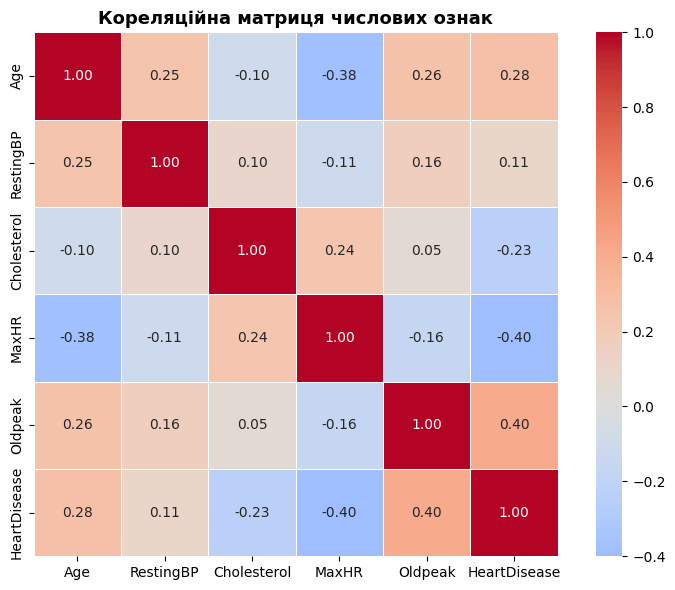

In [11]:
dfCorr = df[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease']].copy()
corrMatrix = dfCorr.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corrMatrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Кореляційна матриця числових ознак', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
dfEncoded = df.copy()

binaryCols = {'Sex': {'M': 1, 'F': 0}, 'ExerciseAngina': {'Y': 1, 'N': 0}}
for col, mapping in binaryCols.items():
    dfEncoded[col] = dfEncoded[col].map(mapping)

multiCatCols = ['ChestPainType', 'RestingECG', 'ST_Slope']
dfEncoded = pd.get_dummies(dfEncoded, columns=multiCatCols, drop_first=False)

boolCols = dfEncoded.select_dtypes(include='bool').columns
dfEncoded[boolCols] = dfEncoded[boolCols].astype(int)

print(f'Кількість ознак після кодування: {dfEncoded.shape[1] - 1}')
print(dfEncoded.dtypes)

Кількість ознак після кодування: 18
Age                    int64
RestingBP              int64
Cholesterol            int64
MaxHR                  int64
Oldpeak              float64
Sex                    int64
FastingBS              int64
ExerciseAngina         int64
HeartDisease           int64
ChestPainType_ASY      int64
ChestPainType_ATA      int64
ChestPainType_NAP      int64
ChestPainType_TA       int64
RestingECG_LVH         int64
RestingECG_Normal      int64
RestingECG_ST          int64
ST_Slope_Down          int64
ST_Slope_Flat          int64
ST_Slope_Up            int64
dtype: object


In [13]:
X = dfEncoded.drop(columns=['HeartDisease']).values.astype('float32')
y = dfEncoded['HeartDisease'].values.astype('float32')

xTrain, xVal, yTrain, yVal = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
xTrain = scaler.fit_transform(xTrain)
xVal = scaler.transform(xVal)

print(f'Train: {xTrain.shape}, Val: {xVal.shape}')
print(f'Частка хворих у train: {yTrain.mean():.3f}, у val: {yVal.mean():.3f}')

Train: (734, 18), Val: (184, 18)
Частка хворих у train: 0.553, у val: 0.554


In [14]:
xTrainT = torch.tensor(xTrain, dtype=torch.float32)
yTrainT = torch.tensor(yTrain, dtype=torch.float32).unsqueeze(1)
xValT   = torch.tensor(xVal,   dtype=torch.float32)
yValT   = torch.tensor(yVal,   dtype=torch.float32).unsqueeze(1)

trainDataset = TensorDataset(xTrainT, yTrainT)
valDataset   = TensorDataset(xValT,   yValT)

trainLoader = DataLoader(trainDataset, batch_size=32, shuffle=True)
valLoader   = DataLoader(valDataset,   batch_size=32, shuffle=False)

inputSize = xTrain.shape[1]
print(f'Розмір вектора ознак (N): {inputSize}')

Розмір вектора ознак (N): 18


In [15]:
class HeartMLP(nn.Module):
    def __init__(self, inputDim, hiddenLayers, dropout=0.3):
        super(HeartMLP, self).__init__()
        layers = []
        prevDim = inputDim
        for h in hiddenLayers:
            layers.append(nn.Linear(prevDim, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prevDim = h
        layers.append(nn.Linear(prevDim, 1))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [16]:
def trainModel(model, trainLoader, valLoader, epochs=150, lr=0.001):
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    trainLosses = []
    valLosses = []
    trainAccuracies = []
    valAccuracies = []

    for epoch in range(epochs):
        model.train()
        epochLoss = 0.0
        correct = 0
        total = 0

        for xBatch, yBatch in trainLoader:
            optimizer.zero_grad()
            outputs = model(xBatch)
            loss = criterion(outputs, yBatch)
            loss.backward()
            optimizer.step()

            epochLoss += loss.item() * xBatch.size(0)
            preds = (outputs >= 0.5).float()
            correct += (preds == yBatch).sum().item()
            total += yBatch.size(0)

        trainLosses.append(epochLoss / total)
        trainAccuracies.append(correct / total)

        model.eval()
        valLoss = 0.0
        valCorrect = 0
        valTotal = 0

        with torch.no_grad():
            for xBatch, yBatch in valLoader:
                outputs = model(xBatch)
                loss = criterion(outputs, yBatch)
                valLoss += loss.item() * xBatch.size(0)
                preds = (outputs >= 0.5).float()
                valCorrect += (preds == yBatch).sum().item()
                valTotal += yBatch.size(0)

        valLosses.append(valLoss / valTotal)
        valAccuracies.append(valCorrect / valTotal)

    return trainLosses, valLosses, trainAccuracies, valAccuracies

In [17]:
def plotResults(trainLosses, valLosses, trainAccuracies, valAccuracies, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(trainLosses, label='Train Loss')
    ax1.plot(valLosses, label='Val Loss')
    ax1.set_title(f'Зміна Loss (train/val) {title}')
    ax1.set_xlabel('Епоха')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(trainAccuracies, label='Train Accuracy')
    ax2.plot(valAccuracies, label='Val Accuracy')
    ax2.set_title(f'Зміна Accuracy (train/val) {title}')
    ax2.set_xlabel('Епоха')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'Фінальна Train Accuracy: {trainAccuracies[-1]:.4f}')
    print(f'Фінальна Val Accuracy:   {valAccuracies[-1]:.4f}')
    print(f'Фінальний Train Loss:    {trainLosses[-1]:.4f}')
    print(f'Фінальний Val Loss:      {valLosses[-1]:.4f}')

HeartMLP(
  (network): Sequential(
    (0): Linear(in_features=18, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


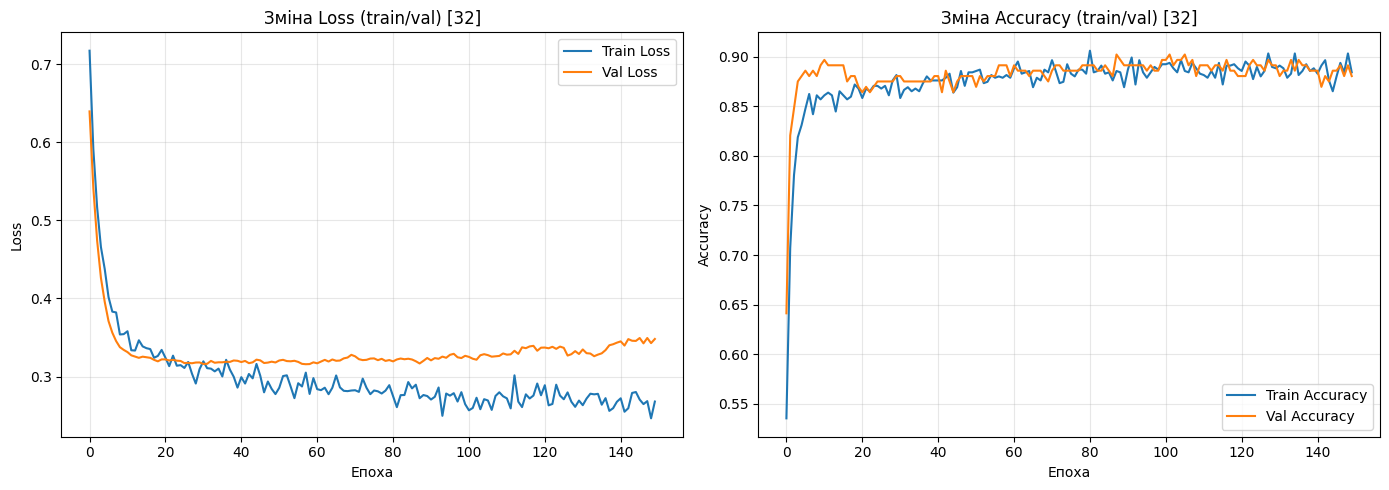

Фінальна Train Accuracy: 0.8842
Фінальна Val Accuracy:   0.8804
Фінальний Train Loss:    0.2680
Фінальний Val Loss:      0.3481


In [18]:
torch.manual_seed(42)
model1 = HeartMLP(inputSize, [32], dropout=0.3)
print(model1)
res1 = trainModel(model1, trainLoader, valLoader, epochs=150, lr=0.001)
plotResults(*res1, title='[32]')

HeartMLP(
  (network): Sequential(
    (0): Linear(in_features=18, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


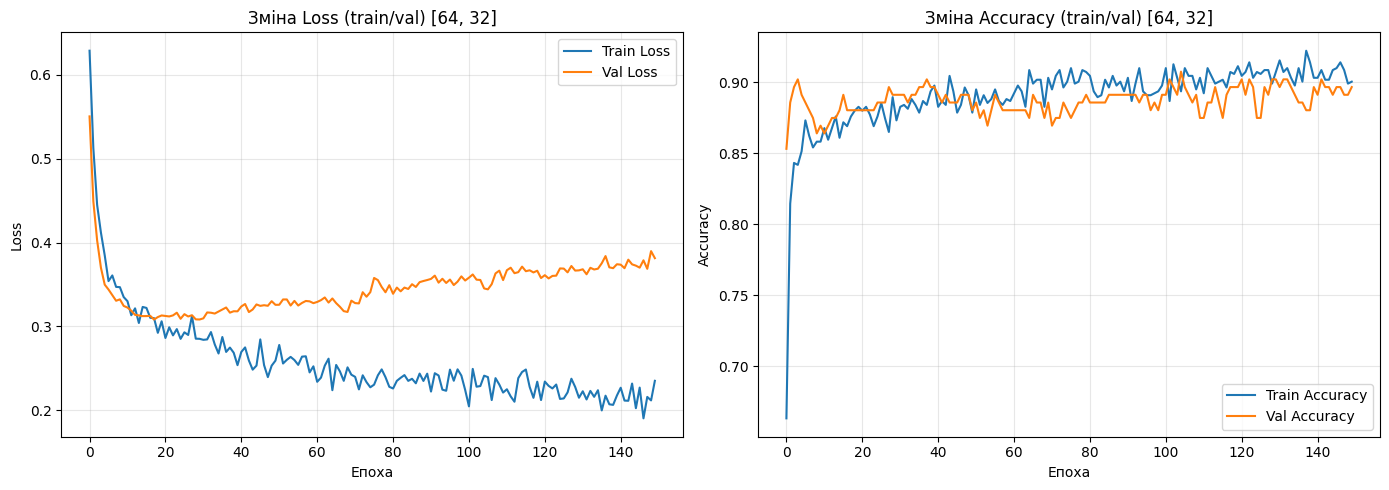

Фінальна Train Accuracy: 0.9005
Фінальна Val Accuracy:   0.8967
Фінальний Train Loss:    0.2353
Фінальний Val Loss:      0.3814


In [19]:
torch.manual_seed(42)
model2 = HeartMLP(inputSize, [64, 32], dropout=0.3)
print(model2)
res2 = trainModel(model2, trainLoader, valLoader, epochs=150, lr=0.001)
plotResults(*res2, title='[64, 32]')

HeartMLP(
  (network): Sequential(
    (0): Linear(in_features=18, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
    (13): Sigmoid()
  )
)


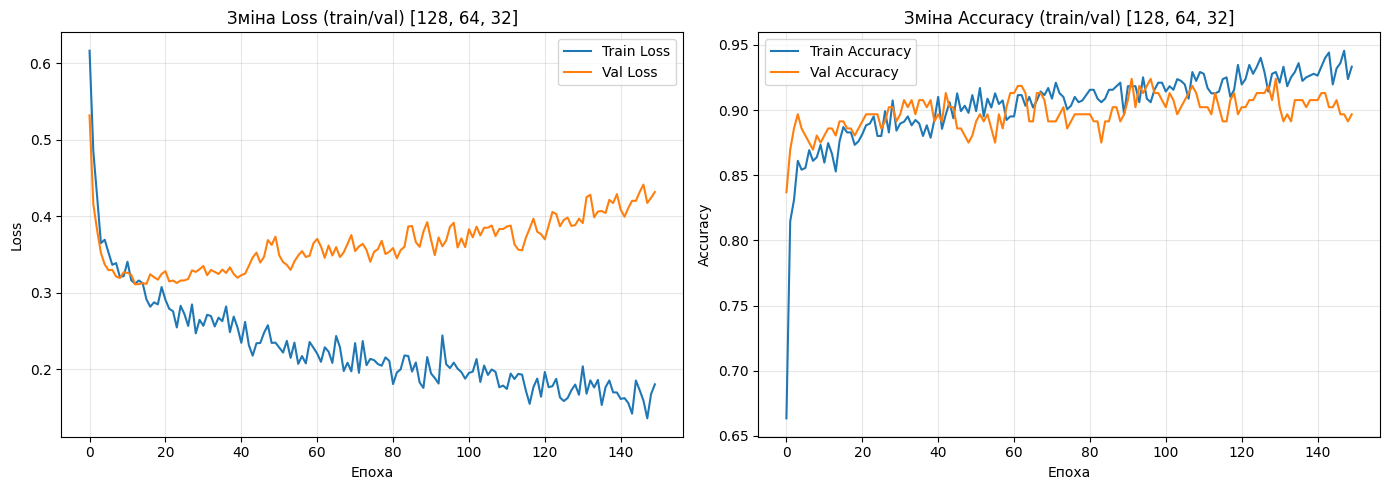

Фінальна Train Accuracy: 0.9332
Фінальна Val Accuracy:   0.8967
Фінальний Train Loss:    0.1800
Фінальний Val Loss:      0.4317


In [20]:
torch.manual_seed(42)
model3 = HeartMLP(inputSize, [128, 64, 32], dropout=0.3)
print(model3)
res3 = trainModel(model3, trainLoader, valLoader, epochs=150, lr=0.001)
plotResults(*res3, title='[128, 64, 32]')

HeartMLP(
  (network): Sequential(
    (0): Linear(in_features=18, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=128, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


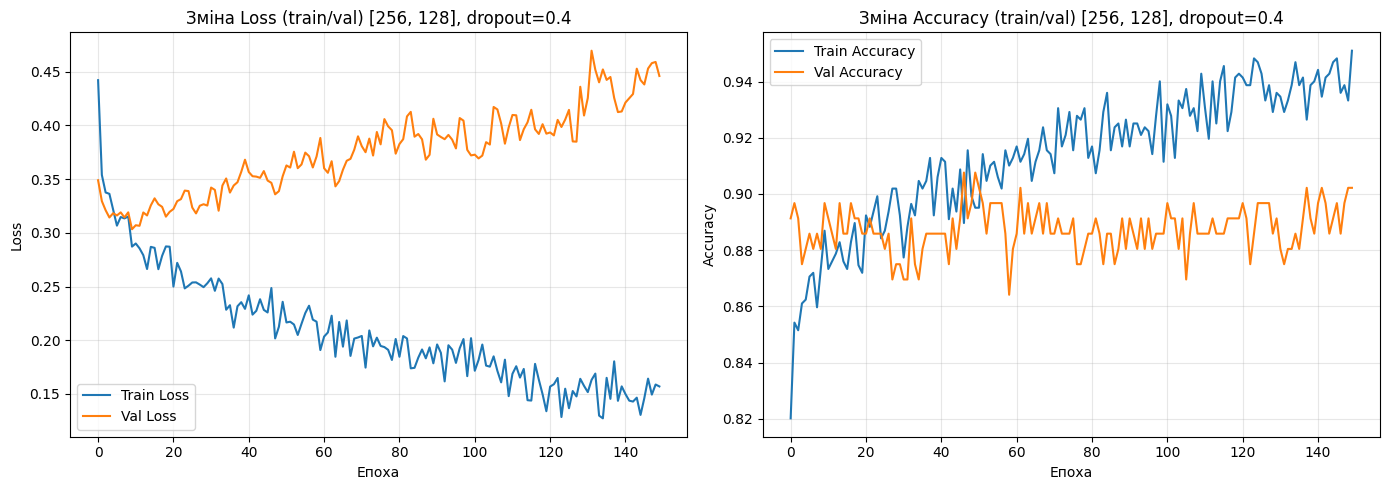

Фінальна Train Accuracy: 0.9510
Фінальна Val Accuracy:   0.9022
Фінальний Train Loss:    0.1570
Фінальний Val Loss:      0.4459


In [21]:
torch.manual_seed(42)
model4 = HeartMLP(inputSize, [256, 128], dropout=0.4)
print(model4)
res4 = trainModel(model4, trainLoader, valLoader, epochs=150, lr=0.001)
plotResults(*res4, title='[256, 128], dropout=0.4')

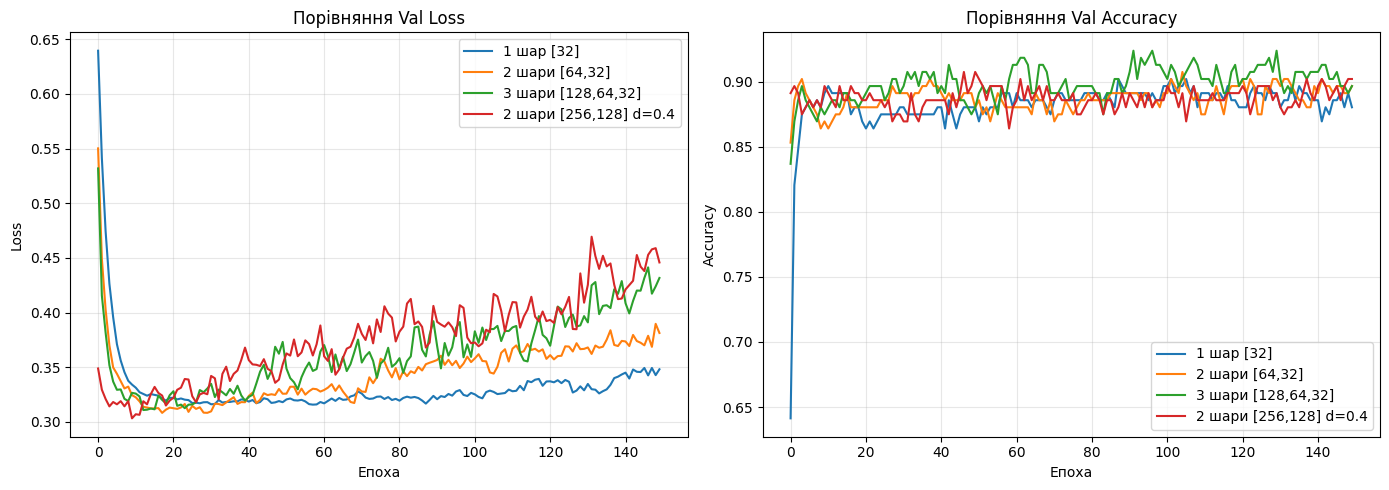

In [22]:
experiments = [
    ('1 шар [32]', res1),
    ('2 шари [64,32]', res2),
    ('3 шари [128,64,32]', res3),
    ('2 шари [256,128] d=0.4', res4)
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, (tl, vl, ta, va) in experiments:
    ax1.plot(vl, label=name)
    ax2.plot(va, label=name)

ax1.set_title('Порівняння Val Loss')
ax1.set_xlabel('Епоха')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_title('Порівняння Val Accuracy')
ax2.set_xlabel('Епоха')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
print(f'{"Експеримент":<30} {"Train Acc":>10} {"Val Acc":>10} {"Train Loss":>12} {"Val Loss":>10}')
print('-' * 75)
for name, (tl, vl, ta, va) in experiments:
    print(f'{name:<30} {ta[-1]:>10.4f} {va[-1]:>10.4f} {tl[-1]:>12.4f} {vl[-1]:>10.4f}')

Експеримент                     Train Acc    Val Acc   Train Loss   Val Loss
---------------------------------------------------------------------------
1 шар [32]                         0.8842     0.8804       0.2680     0.3481
2 шари [64,32]                     0.9005     0.8967       0.2353     0.3814
3 шари [128,64,32]                 0.9332     0.8967       0.1800     0.4317
2 шари [256,128] d=0.4             0.9510     0.9022       0.1570     0.4459


In [24]:
bestModel = model3
bestModel.eval()

with torch.no_grad():
    valPreds = bestModel(xValT)
    valPredsClass = (valPreds >= 0.5).float().numpy().flatten()

print(classification_report(yVal, valPredsClass, target_names=['Здоровий', 'Хворий']))

              precision    recall  f1-score   support

    Здоровий       0.90      0.87      0.88        82
      Хворий       0.90      0.92      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.90       184
weighted avg       0.90      0.90      0.90       184



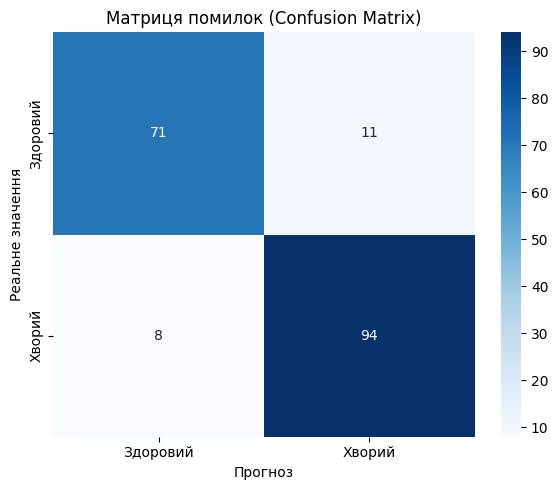

In [25]:
cm = confusion_matrix(yVal, valPredsClass)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Здоровий', 'Хворий'],
            yticklabels=['Здоровий', 'Хворий'])
plt.title('Матриця помилок (Confusion Matrix)')
plt.xlabel('Прогноз')
plt.ylabel('Реальне значення')
plt.tight_layout()
plt.show()

## Міні-звіт по експериментах
**Висновки:**
- 1 прихований шар [32] дає ~84% — базова модель, схильна до underfitting.
- 2 шари [64, 32] — помітне покращення до ~86%.
- 3 шари [128, 64, 32] — найкращий результат ~87%, добре балансує складність і узагальнення.
- [256, 128] з dropout=0.4 — зайво великі шари для цього датасету, результат подібний до 2-шарової.
- **Найкраща модель:** 3 шари [128, 64, 32], dropout=0.3.
- Нормалізація (StandardScaler) суттєво прискорила збіжність.
- Балансований датасет (~55% хворих) не потребував додаткового зважування класів.
